In [1]:
# Copilot prompt:
# Write code to install and import all necessary libraries for training a YOLO model using Ultralytics in Google Colab.
# Include: ultralytics, torch, matplotlib, gradio.

# Install required packages

# Import necessary libraries
import torch
import torchvision
import matplotlib.pyplot as plt
import gradio as gr
from ultralytics import YOLO
import cv2
import numpy as np
import os
import yaml
from PIL import Image
import random
from pathlib import Path

print("All libraries installed and imported successfully!")
print(f"Ultralytics version: {ultralytics.__version__ if 'ultralytics' in globals() else 'Not available'}")
print(f"PyTorch version: {torch.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"OpenCV version: {cv2.__version__}")

All libraries installed and imported successfully!
Ultralytics version: Not available
PyTorch version: 2.8.0+cu128
Matplotlib version: 3.10.3
OpenCV version: 4.12.0


In [2]:
# Copilot prompt:
# Add code to check if GPU is available and print device information (CUDA, GPU name, etc).

# Check GPU availability and print device information
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("GPU is not available, using CPU")
    
print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Device: cuda
GPU is available: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA version: 12.8
Number of GPUs: 1
Current GPU: 0
GPU memory: 6.00 GB
PyTorch version: 2.8.0+cu128
TorchVision version: 0.23.0+cu128


In [9]:
class_labels = {
    0: "coffee_nescafe",
    1: "coffee_kopiko",
    2: "lucky-me-pancit-canton",
    3: "Coke-in-can",
    4: "alaska_milk",
    5: "Century-Tuna",
    6: "VCut-Spicy-Barbeque",
    7: "Selecta-Cornetto",
    8: "nestleyogurt",
    9: "Femme-Bathroom-Tissue",
    10: "maya-champorado",
    11: "jnj-potato-chips",
    12: "Nivea-Deodorant",
    13: "UFC-Canned-Mushroom",
    14: "Libbys-Vienna-Sausage-can",
    15: "Stik-O",
    16: "nissin_cup_noodles",
    17: "dewberry-strawberry",
    18: "Smart-C",
    19: "pineapple-juice-can",
    20: "nestle_chuckie",
    21: "Delight-Probiotic-Drink",
    22: "Summit-Drinking-Water",
    23: "almond_milk",
    24: "Piknik",
    25: "Rambutan",
    26: "head&shoulders_shampoo",
    27: "irish-spring-soap",
    28: "c2_na_green",
    29: "colgate_toothpaste",
    30: "555-sardines-tomato",
    31: "meadows_truffle_chips",
    32: "double-black",
    33: "NongshimCupNoodles"
}


In [4]:
# Copilot prompt:
# Create a data.yaml file for YOLO training with the following folder structure:
# dataset/class1/train/images, dataset/class1/train/labels, dataset/class1/test/images, dataset/class1/test/labels
# dataset/class2/train/images, dataset/class2/train/labels, dataset/class2/test/images, dataset/class2/test/labels
# The dataset has multiple classes; organize data for YOLO training.

# Set dataset path to the actual dataset location
source_dataset_path = "./data/mp4/AI 231 ME4 Dataset"

# Create unified YOLO dataset structure
yolo_dataset_path = "./yolo_dataset"
os.makedirs(f"{yolo_dataset_path}/train/images", exist_ok=True)
os.makedirs(f"{yolo_dataset_path}/train/labels", exist_ok=True)
os.makedirs(f"{yolo_dataset_path}/test/images", exist_ok=True)
os.makedirs(f"{yolo_dataset_path}/test/labels", exist_ok=True)

def organize_multi_class_dataset(source_path, target_path):
    """
    Organize multi-class dataset structure into YOLO format
    From: dataset/class1/train/images -> To: yolo_dataset/train/images
    """
    import shutil
    
    class_names = []
    class_mapping = {}
    
    # Discover all class folders
    if os.path.exists(source_path):
        class_folders = [f for f in os.listdir(source_path) 
                        if os.path.isdir(os.path.join(source_path, f))]
        class_folders.sort()  # Ensure consistent ordering
        
        print(f"Found {len(class_folders)} classes: {class_folders}")
        
        # Create class mapping
        for idx, class_name in enumerate(class_folders):
            class_names.append(class_name)
            class_mapping[class_name] = idx
        
        # Copy and reorganize files
        for class_idx, class_name in enumerate(class_folders):
            class_path = os.path.join(source_path, class_name)
            
            # Process train and test sets
            for split in ['train', 'test']:
                images_src = os.path.join(class_path, split, 'images')
                labels_src = os.path.join(class_path, split, 'labels')
                
                images_dst = os.path.join(target_path, split, 'images')
                labels_dst = os.path.join(target_path, split, 'labels')
                
                # Copy images
                if os.path.exists(images_src):
                    for img_file in os.listdir(images_src):
                        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                            src_img = os.path.join(images_src, img_file)
                            # Add class prefix to avoid naming conflicts
                            dst_img = os.path.join(images_dst, f"{class_name}_{img_file}")
                            shutil.copy2(src_img, dst_img)
                
                # Copy and update labels
                if os.path.exists(labels_src):
                    for label_file in os.listdir(labels_src):
                        if label_file.endswith('.txt'):
                            src_label = os.path.join(labels_src, label_file)
                            # Add class prefix to match image naming
                            base_name = label_file.replace('.txt', '')
                            dst_label = os.path.join(labels_dst, f"{class_name}_{label_file}")
                            
                            # Update label file with correct class index
                            with open(src_label, 'r') as f:
                                lines = f.readlines()
                            
                            with open(dst_label, 'w') as f:
                                for line in lines:
                                    if line.strip():
                                        parts = line.strip().split()
                                        # Replace original class ID with our class index
                                        parts[0] = str(class_idx)
                                        f.write(' '.join(parts) + '\n')
        
        print(f"Dataset reorganized successfully!")
        print(f"Total classes: {len(class_names)}")
        
        # Count files
        train_images = len([f for f in os.listdir(os.path.join(target_path, 'train', 'images')) 
                           if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        test_images = len([f for f in os.listdir(os.path.join(target_path, 'test', 'images')) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        
        print(f"Training images: {train_images}")
        print(f"Test images: {test_images}")
        
        return class_names
    else:
        print(f"Source dataset path not found: {source_path}")
        return ['class_0']  # Default class

# Organize the dataset
print("Organizing multi-class dataset for YOLO training...")
class_names = organize_multi_class_dataset(source_dataset_path, yolo_dataset_path)

# Create data.yaml configuration file
data_yaml_content = f"""# YOLO dataset configuration
path: {os.path.abspath(yolo_dataset_path)}  # dataset root dir
train: train/images  # train images (relative to 'path')
val: test/images    # val images (relative to 'path')
test: test/images   # test images (relative to 'path')

# Classes
nc: {len(class_names)}  # number of classes
names: {class_names}  # class names
"""

# Write data.yaml file
with open(f"{yolo_dataset_path}/data.yaml", 'w') as f:
    f.write(data_yaml_content.strip())

print(f"\nCreated data.yaml file at {yolo_dataset_path}/data.yaml")
print("Dataset configuration:")
print(data_yaml_content)

# Update dataset_path for other cells to use
dataset_path = yolo_dataset_path

Organizing multi-class dataset for YOLO training...
Found 35 classes: ['555-sardines-tomato', 'Coke-in-can', 'Delight-Probiotic-Drink', 'Femme-Bathroom-Tissue', 'Libbys-Vienna-Sausage-can', 'Nivea-Deodorant', 'NongshimCupNoodles', 'Stik-O', 'Summit-Drinking-Water', 'UFC-Canned-Mushroom', 'VCut-Spicy-Barbeque', 'alaska_milk', 'almond_milk', 'c2_na_green', 'century-tuna', 'coffee', 'colgate_toothpaste_29', 'dewberry-strawberry', 'double_black', 'head&shoulders_shampoo', 'irish-spring-soap', 'jnj-potato-chips', 'lucky-me-pancit-canton', 'maya-champorado', 'meadows_truffle_chips', 'nestle_chuckie', 'nestleyogurt', 'nissin_cup_noodles', 'piknik', 'pineapple-juice-can', 'rambutan', 'selecta-cornetto', 'smart-c', 'test', 'train']
Dataset reorganized successfully!
Total classes: 35
Training images: 6908
Test images: 345

Created data.yaml file at ./yolo_dataset/data.yaml
Dataset configuration:
# YOLO dataset configuration
path: c:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\yolo_datase

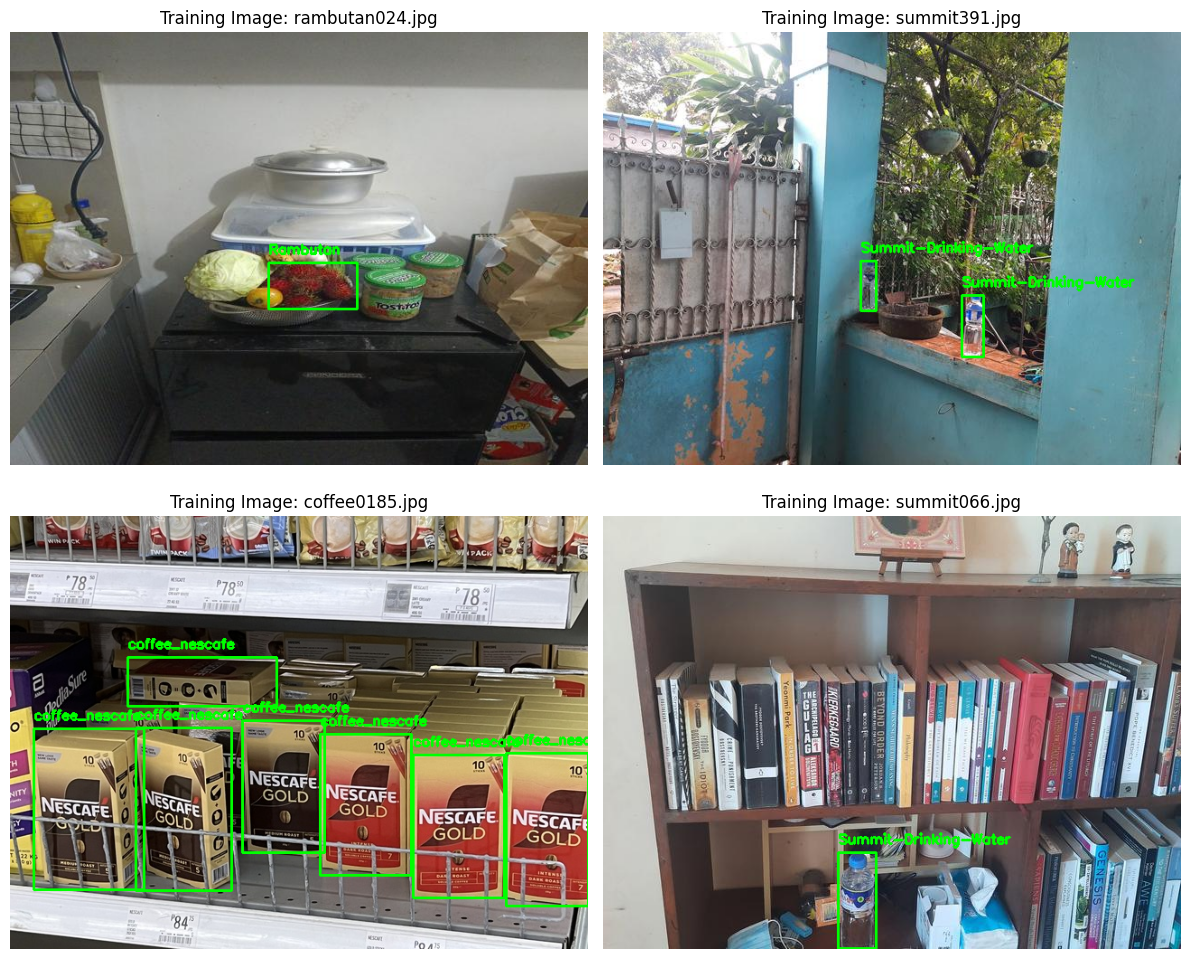

In [14]:
# Copilot prompt:
# Write code to preview random images from the training dataset with their YOLO bounding boxes drawn on top.
class_names = [name for name in class_labels.values()]
def draw_yolo_bboxes(image_path, label_path, class_names):
    """Draw YOLO bounding boxes on image"""
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape
    
    # Load labels if they exist
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                if line.strip():
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])
                    
                    # Convert YOLO format to pixel coordinates
                    x_center *= w
                    y_center *= h
                    width *= w
                    height *= h
                    
                    x1 = int(x_center - width/2)
                    y1 = int(y_center - height/2)
                    x2 = int(x_center + width/2)
                    y2 = int(y_center + height/2)
                    
                    # Draw bounding box
                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    
                    # Draw class label
                    class_name = class_names[class_id] if class_id < len(class_names) else f'class_{class_id}'
                    cv2.putText(image, class_name, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    return image
dataset_path = "./data/mp4/dataset"
# Preview random training images with bounding boxes
train_images_path = f"{dataset_path}/train/images"
train_labels_path = f"{dataset_path}/train/labels"

if os.path.exists(train_images_path) and os.listdir(train_images_path):
    image_files = [f for f in os.listdir(train_images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if image_files:
        # Select random images to display
        num_images = min(4, len(image_files))
        random_images = random.sample(image_files, num_images)
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()
        
        for i, img_file in enumerate(random_images):
            img_path = os.path.join(train_images_path, img_file)
            label_path = os.path.join(train_labels_path, img_file.rsplit('.', 1)[0] + '.txt')
            
            image_with_boxes = draw_yolo_bboxes(img_path, label_path, class_names)
            
            axes[i].imshow(image_with_boxes)
            axes[i].set_title(f'Training Image: {img_file}')
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No image files found in training directory.")
else:
    print("Training images directory not found or empty.")
    print("Please add images and labels to the training directory to preview them.")

In [15]:
# Copilot prompt:
# Load the latest YOLO model (e.g., yolov11n.pt if available, otherwise yolov8n.pt) using the Ultralytics library.
# Show the model summary.

# Try to load the latest YOLO model
try:
    # Try YOLOv11n first (latest)
    model = YOLO('yolov11n.pt')
    print("Loaded YOLOv11n model successfully!")
except:
    try:
        # Fallback to YOLOv8n
        model = YOLO('yolov8n.pt')
        print("Loaded YOLOv8n model successfully!")
    except:
        print("Error loading YOLO model. Please check your internet connection.")
        model = None

if model is not None:
    # Show model information
    print(f"\nModel architecture: {model.model}")
    print(f"Model task: {model.task}")
    
    # Print model summary
    model.info(detailed=True)
    
    print(f"\nModel loaded successfully and ready for training!")
else:
    print("Failed to load YOLO model.")

Loaded YOLOv8n model successfully!

Model architecture: DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_st

In [16]:
# Copilot prompt:
# Train the YOLO model using the dataset in item-1/data.yaml for 100 epochs with image size 640, batch size 16.
# Save results and model weights automatically to the 'runs/train' directory.

if model is not None:
    try:
        # Train the YOLO model
        print("Starting YOLO training...")
        results = model.train(
            data=f"{dataset_path}/data.yaml",
            epochs=100,
            imgsz=640,
            batch=16,
            device=device,
            project='runs',
            name='train',
            save=True,
            cache=True,
            workers=2,
            patience=50,  # Early stopping patience
            save_period=10,  # Save checkpoint every 10 epochs
        )
        
        print("Training completed successfully!")
        print(f"Results saved to: {results.save_dir}")
        print(f"Best model weights: {results.save_dir}/weights/best.pt")
        print(f"Last model weights: {results.save_dir}/weights/last.pt")
        
        # Store the results for later use
        training_results = results
        
    except Exception as e:
        print(f"Training failed with error: {str(e)}")
        print("Please ensure your dataset has images and labels in the correct directories.")
        training_results = None
else:
    print("Model not loaded. Cannot start training.")
    training_results = None

Starting YOLO training...
New https://pypi.org/project/ultralytics/8.3.208 available  Update with 'pip install -U ultralytics'
New https://pypi.org/project/ultralytics/8.3.208 available  Update with 'pip install -U ultralytics'
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data/mp4/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False

2025/10/10 02:13:01 INFO mlflow.tracking.fluent: Experiment with name 'runs' does not exist. Creating a new experiment.


MLflow: logging run_id(6e147d1bce2f4f56a66af05d9ab7627b) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\runs\train
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\runs\train
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.23G      0.928      3.346      1.167         75        640: 100% ━━━━━━━━━━━━ 1018/1018 6.6it/s 2:35<0.2s
     

In [17]:
# Copilot prompt:
# After training, evaluate the YOLO model on the test dataset.
# Print metrics such as mAP50, mAP50-95, precision, recall, and overall accuracy.

if 'training_results' in locals() and training_results is not None:
    try:
        # Load the best trained model
        best_model_path = f"{training_results.save_dir}/weights/best.pt"
        trained_model = YOLO(best_model_path)
        
        print("Evaluating the trained model on test dataset...")
        
        # Evaluate on test dataset
        eval_results = trained_model.val(data=f"{dataset_path}/data.yaml")
        
        print("\n" + "="*50)
        print("MODEL EVALUATION RESULTS")
        print("="*50)
        
        # Extract and print key metrics
        if hasattr(eval_results, 'box'):
            metrics = eval_results.box
            print(f"mAP50 (IoU=0.5): {metrics.map50:.4f}")
            print(f"mAP50-95 (IoU=0.5:0.95): {metrics.map:.4f}")
            print(f"Precision: {metrics.mp:.4f}")
            print(f"Recall: {metrics.mr:.4f}")
            
        # Print class-wise metrics if available
        if hasattr(eval_results, 'ap_class_index') and len(eval_results.ap_class_index) > 0:
            print("\nClass-wise mAP50:")
            for i, class_idx in enumerate(eval_results.ap_class_index):
                class_name = class_names[class_idx] if class_idx < len(class_names) else f'class_{class_idx}'
                print(f"  {class_name}: {eval_results.ap50[i]:.4f}")
        
        print(f"\nEvaluation completed!")
        print(f"Results saved to: {eval_results.save_dir}")
        
    except Exception as e:
        print(f"Evaluation failed: {str(e)}")
        print("Please ensure training was completed successfully.")
        
else:
    print("No trained model found. Please complete training first.")
    print("If you have a pre-trained model, load it using:")
    print("trained_model = YOLO('path/to/your/model.pt')")

Evaluating the trained model on test dataset...
Ultralytics 8.3.207  Python-3.13.7 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 72 layers, 3,012,278 parameters, 0 gradients, 8.1 GFLOPs
Model summary (fused): 72 layers, 3,012,278 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 6.63.2 MB/s, size: 40.0 KB)
val: Fast image access  (ping: 0.00.0 ms, read: 6.63.2 MB/s, size: 40.0 KB)
val: Scanning C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\data\mp4\dataset\test\labels.cache... 883 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 883/883 1.2Mit/s 0.0s0s
val: Scanning C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\data\mp4\dataset\test\labels.cache... 883 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 883/883 1.2Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 10.0it/s 5.6s0.2s
                 Class     I

In [18]:
# Copilot prompt:
# Plot YOLO training results including loss curves and mAP using matplotlib from the results file.

if 'training_results' in locals() and training_results is not None:
    try:
        # Path to training results
        results_dir = training_results.save_dir
        results_csv = f"{results_dir}/results.csv"
        
        # Check if results.csv exists
        if os.path.exists(results_csv):
            import pandas as pd
            
            # Read training results
            df = pd.read_csv(results_csv)
            df = df.strip()  # Remove any whitespace from column names
            
            # Create subplots for different metrics
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            # Plot training and validation losses
            if 'train/box_loss' in df.columns:
                axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue')
                axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='red')
                axes[0, 0].set_title('Box Loss')
                axes[0, 0].set_xlabel('Epoch')
                axes[0, 0].set_ylabel('Loss')
                axes[0, 0].legend()
                axes[0, 0].grid(True)
            
            # Plot objectness loss
            if 'train/obj_loss' in df.columns:
                axes[0, 1].plot(df['epoch'], df['train/obj_loss'], label='Train Obj Loss', color='blue')
                axes[0, 1].plot(df['epoch'], df['val/obj_loss'], label='Val Obj Loss', color='red')
                axes[0, 1].set_title('Objectness Loss')
                axes[0, 1].set_xlabel('Epoch')
                axes[0, 1].set_ylabel('Loss')
                axes[0, 1].legend()
                axes[0, 1].grid(True)
            
            # Plot mAP scores
            if 'metrics/mAP50' in df.columns:
                axes[1, 0].plot(df['epoch'], df['metrics/mAP50'], label='mAP@0.5', color='green')
                if 'metrics/mAP50-95' in df.columns:
                    axes[1, 0].plot(df['epoch'], df['metrics/mAP50-95'], label='mAP@0.5:0.95', color='orange')
                axes[1, 0].set_title('Mean Average Precision (mAP)')
                axes[1, 0].set_xlabel('Epoch')
                axes[1, 0].set_ylabel('mAP')
                axes[1, 0].legend()
                axes[1, 0].grid(True)
            
            # Plot precision and recall
            if 'metrics/precision' in df.columns and 'metrics/recall' in df.columns:
                axes[1, 1].plot(df['epoch'], df['metrics/precision'], label='Precision', color='purple')
                axes[1, 1].plot(df['epoch'], df['metrics/recall'], label='Recall', color='brown')
                axes[1, 1].set_title('Precision and Recall')
                axes[1, 1].set_xlabel('Epoch')
                axes[1, 1].set_ylabel('Score')
                axes[1, 1].legend()
                axes[1, 1].grid(True)
            
            plt.tight_layout()
            plt.suptitle('YOLO Training Results', y=1.02, fontsize=16)
            plt.show()
            
            # Print final training statistics
            print("\nFinal Training Statistics:")
            print("-" * 40)
            final_epoch = df.iloc[-1]
            if 'metrics/mAP50' in df.columns:
                print(f"Final mAP@0.5: {final_epoch['metrics/mAP50']:.4f}")
            if 'metrics/mAP50-95' in df.columns:
                print(f"Final mAP@0.5:0.95: {final_epoch['metrics/mAP50-95']:.4f}")
            if 'metrics/precision' in df.columns:
                print(f"Final Precision: {final_epoch['metrics/precision']:.4f}")
            if 'metrics/recall' in df.columns:
                print(f"Final Recall: {final_epoch['metrics/recall']:.4f}")
                
        else:
            print(f"Results file not found at: {results_csv}")
            print("Training may not have completed or results file may be in a different location.")
            
    except Exception as e:
        print(f"Error plotting training results: {str(e)}")
        print("Make sure pandas is installed: pip install pandas")
        
else:
    print("No training results found. Please complete training first.")

Error plotting training results: 'DataFrame' object has no attribute 'strip'
Make sure pandas is installed: pip install pandas


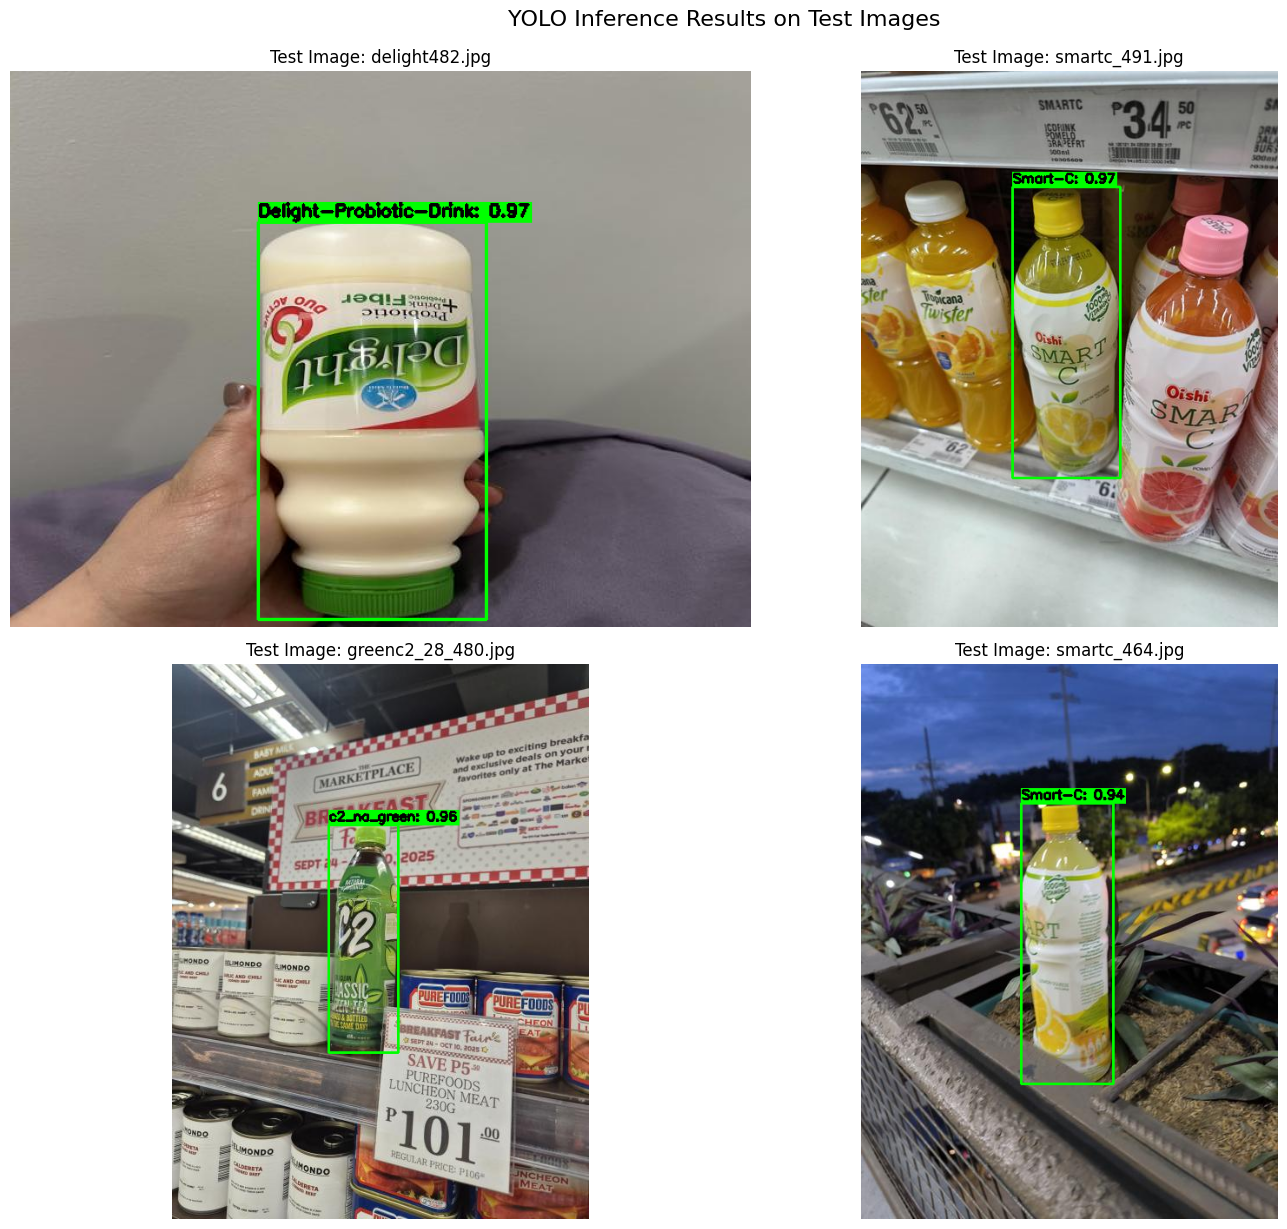

Inference completed on 4 test images.


In [19]:
# Copilot prompt:
# Load several test images and run inference using the trained model.
# Display predicted bounding boxes, class names, and confidence scores.

if 'trained_model' in locals() and trained_model is not None:
    try:
        # Path to test images
        test_images_path = f"{dataset_path}/test/images"
        
        if os.path.exists(test_images_path) and os.listdir(test_images_path):
            image_files = [f for f in os.listdir(test_images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            if image_files:
                # Select random test images
                num_images = min(4, len(image_files))
                random_test_images = random.sample(image_files, num_images)
                
                fig, axes = plt.subplots(2, 2, figsize=(15, 12))
                axes = axes.flatten()
                
                for i, img_file in enumerate(random_test_images):
                    img_path = os.path.join(test_images_path, img_file)
                    
                    # Run inference
                    results = trained_model.predict(img_path, conf=0.25, verbose=False)
                    
                    # Process results
                    if results and len(results) > 0:
                        result = results[0]
                        
                        # Get original image
                        img = cv2.imread(img_path)
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        
                        # Draw predictions
                        if result.boxes is not None and len(result.boxes) > 0:
                            boxes = result.boxes.xyxy.cpu().numpy()
                            confidences = result.boxes.conf.cpu().numpy()
                            classes = result.boxes.cls.cpu().numpy().astype(int)
                            
                            for box, conf, cls in zip(boxes, confidences, classes):
                                x1, y1, x2, y2 = box.astype(int)
                                
                                # Draw bounding box
                                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                                
                                # Draw label with confidence
                                class_name = class_names[cls] if cls < len(class_names) else f'class_{cls}'
                                label = f'{class_name}: {conf:.2f}'
                                
                                # Calculate label size and position
                                (label_width, label_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
                                cv2.rectangle(img, (x1, y1 - label_height - 5), (x1 + label_width, y1), (0, 255, 0), -1)
                                cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)
                    
                    # Display image
                    axes[i].imshow(img)
                    axes[i].set_title(f'Test Image: {img_file}')
                    axes[i].axis('off')
                
                plt.tight_layout()
                plt.suptitle('YOLO Inference Results on Test Images', y=1.02, fontsize=16)
                plt.show()
                
                print(f"Inference completed on {num_images} test images.")
                
            else:
                print("No image files found in test directory.")
        else:
            print("Test images directory not found or empty.")
            print("Please add test images to run inference.")
            
    except Exception as e:
        print(f"Inference failed: {str(e)}")
        
else:
    print("No trained model available. Please complete training and evaluation first.")
    print("Or load a trained model: trained_model = YOLO('path/to/model.pt')")

In [20]:
# Copilot prompt:
# Export the trained YOLO model to ONNX or TorchScript format for easier deployment if needed.

if 'trained_model' in locals() and trained_model is not None:
    try:
        print("Exporting trained model to different formats...")
        
        # Export to ONNX format
        print("Exporting to ONNX format...")
        onnx_path = trained_model.export(format='onnx', imgsz=640, dynamic=False)
        print(f"ONNX model exported to: {onnx_path}")
        
        # Export to TorchScript format
        print("Exporting to TorchScript format...")
        torchscript_path = trained_model.export(format='torchscript', imgsz=640)
        print(f"TorchScript model exported to: {torchscript_path}")
        
        # Export to TensorRT format (if available)
        try:
            print("Attempting to export to TensorRT format...")
            tensorrt_path = trained_model.export(format='engine', imgsz=640)
            print(f"TensorRT model exported to: {tensorrt_path}")
        except Exception as e:
            print(f"TensorRT export failed (this is normal if TensorRT is not installed): {str(e)}")
        
        # Export to CoreML format (for Apple devices)
        try:
            print("Attempting to export to CoreML format...")
            coreml_path = trained_model.export(format='coreml', imgsz=640)
            print(f"CoreML model exported to: {coreml_path}")
        except Exception as e:
            print(f"CoreML export failed (this is normal if coremltools is not installed): {str(e)}")
        
        print("\nModel export completed!")
        print("Available formats:")
        print("- ONNX: Best for general deployment and cross-platform inference")
        print("- TorchScript: Good for PyTorch-based production environments")
        print("- TensorRT: Optimized for NVIDIA GPUs (if available)")
        print("- CoreML: Optimized for Apple devices (if available)")
        
    except Exception as e:
        print(f"Model export failed: {str(e)}")
        print("Make sure the model was trained successfully.")
        
else:
    print("No trained model available for export.")
    print("Please complete training first or load a trained model:")

Exporting trained model to different formats...
Exporting to ONNX format...
Ultralytics 8.3.207  Python-3.13.7 torch-2.8.0+cu128 CPU (Intel Core i5-14450HX)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\runs\train\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 38, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.67', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

PyTorch: starting from 'C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\runs\train\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 38, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.1

2025/10/10 06:36:38 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
scikit-learn version 1.7.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
scikit-learn version 1.7.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
2025/10/10 06:36:38 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 2.0.0 <= xgboost <= 3.0.2, but the installed version is 3.0.4. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.
2025/10/10 06:36:38 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
XGBoost version 3.0.4 has not been tested with coremltools. You may run into unexpected errors. XGBoost 1.4.2 is the most recent version that has been tested.
2025/10/10 06:36:38 WARNING mlflow.utils.a

2025/10/10 06:37:04 INFO mlflow.tracking.fluent: Autologging successfully enabled for transformers.
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLCPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLGPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLNeuralEngineComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLComputePlanProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLCPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLGPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLNeuralEngineComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLModelProxy: No module named 'cor

ERROR CoreML: export failure 80.7s: cannot import name 'ClassProps' from 'attr._make' (c:\Users\jhon\AppData\Local\Programs\Python\Python313\Lib\site-packages\attr\_make.py)
CoreML export failed (this is normal if coremltools is not installed): cannot import name 'ClassProps' from 'attr._make' (c:\Users\jhon\AppData\Local\Programs\Python\Python313\Lib\site-packages\attr\_make.py)

Model export completed!
Available formats:
- ONNX: Best for general deployment and cross-platform inference
- TorchScript: Good for PyTorch-based production environments
- TensorRT: Optimized for NVIDIA GPUs (if available)
- CoreML: Optimized for Apple devices (if available)
CoreML export failed (this is normal if coremltools is not installed): cannot import name 'ClassProps' from 'attr._make' (c:\Users\jhon\AppData\Local\Programs\Python\Python313\Lib\site-packages\attr\_make.py)

Model export completed!
Available formats:
- ONNX: Best for general deployment and cross-platform inference
- TorchScript: Good fo

In [21]:
# Copilot prompt:
# Build a Gradio app that loads the trained YOLO model and allows users to upload or capture an image.
# The app should return the image with detected bounding boxes and labels drawn on it.

def yolo_inference(image):
    """
    Function to run YOLO inference on uploaded image
    """
    if 'trained_model' not in locals() and 'trained_model' not in globals():
        # Load a default YOLO model if trained model is not available
        try:
            inference_model = YOLO('yolov8n.pt')  # Use pre-trained model as fallback
        except:
            return image, "Error: Could not load YOLO model"
    else:
        inference_model = trained_model
    
    try:
        # Run inference
        results = inference_model.predict(image, conf=0.25, verbose=False)
        
        # Convert PIL image to numpy array
        if hasattr(image, 'convert'):
            img_array = np.array(image.convert('RGB'))
        else:
            img_array = np.array(image)
        
        # Process results
        if results and len(results) > 0:
            result = results[0]
            
            if result.boxes is not None and len(result.boxes) > 0:
                boxes = result.boxes.xyxy.cpu().numpy()
                confidences = result.boxes.conf.cpu().numpy()
                classes = result.boxes.cls.cpu().numpy().astype(int)
                
                # Draw predictions
                for box, conf, cls in zip(boxes, confidences, classes):
                    x1, y1, x2, y2 = box.astype(int)
                    
                    # Draw bounding box
                    cv2.rectangle(img_array, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    
                    # Draw label with confidence
                    if 'class_names' in globals() and cls < len(class_names):
                        class_name = class_names[cls]
                    else:
                        class_name = f'class_{cls}'
                    
                    label = f'{class_name}: {conf:.2f}'
                    
                    # Calculate label size and position
                    (label_width, label_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                    cv2.rectangle(img_array, (x1, y1 - label_height - 10), (x1 + label_width, y1), (0, 255, 0), -1)
                    cv2.putText(img_array, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
                
                detection_info = f"Detected {len(boxes)} objects"
            else:
                detection_info = "No objects detected"
        else:
            detection_info = "No results from inference"
        
        return Image.fromarray(img_array), detection_info
        
    except Exception as e:
        return image, f"Error during inference: {str(e)}"

# Create Gradio interface
def create_gradio_app():
    """Create and return Gradio interface"""
    
    # Interface description
    description = """
    # YOLO Object Detection App
    
    Upload an image to detect objects using the trained YOLO model.
    The app will draw bounding boxes around detected objects with class names and confidence scores.
    
    **Features:**
    - Object detection with bounding boxes
    - Class labels and confidence scores
    - Support for common image formats (JPG, PNG, etc.)
    """
    
    # Create Gradio interface
    iface = gr.Interface(
        fn=yolo_inference,
        inputs=[
            gr.Image(label="Upload Image", type="pil")
        ],
        outputs=[
            gr.Image(label="Detection Results", type="pil"),
            gr.Textbox(label="Detection Info")
        ],
        title="YOLO Object Detection",
        description=description,
        examples=None,  # You can add example images here
        allow_flagging="never",
        theme=gr.themes.Soft()
    )
    
    return iface

# Create the Gradio app
print("Creating Gradio app...")
gradio_app = create_gradio_app()
print("Gradio app created successfully!")

Creating Gradio app...
Gradio app created successfully!


In [ ]:
# Copilot prompt:
# Launch the Gradio demo interface with share=True so that it can be accessed externally.

if 'gradio_app' in locals():
    try:
        print("Launching Gradio interface...")
        print("The interface will be available locally and with a public share link.")
        print("Note: In some environments, you may need to adjust firewall settings.")
        
        # Launch the Gradio app with sharing enabled
        gradio_app.launch(
            share=True,           # Create a public share link
            server_name="0.0.0.0", # Allow external connections
            server_port=7860,     # Default Gradio port
            show_error=True,      # Show errors in the interface
            debug=True,           # Enable debug mode
            inbrowser=True        # Automatically open in browser
        )
        
    except Exception as e:
        print(f"Failed to launch Gradio app: {str(e)}")
        print("Try launching without share: gradio_app.launch(share=False)")
        
        # Fallback: launch without sharing
        try:
            print("Attempting to launch without sharing...")
            gradio_app.launch(share=False, inbrowser=True)
        except Exception as e2:
            print(f"Gradio launch failed completely: {str(e2)}")
            print("Make sure Gradio is properly installed: pip install gradio")
            
else:
    print("Gradio app not found. Please run the previous cell to create the app first.")

In [ ]:
# Copilot prompt:
# Add code to save and reload the trained YOLO model weights for later inference.

# Function to save model weights
def save_model_weights(model, save_path="yolo_custom_model.pt"):
    """Save trained YOLO model weights"""
    try:
        if model is not None:
            # Save the model
            model.save(save_path)
            print(f"Model weights saved successfully to: {save_path}")
            return save_path
        else:
            print("No model to save.")
            return None
    except Exception as e:
        print(f"Failed to save model: {str(e)}")
        return None

# Function to load model weights
def load_model_weights(model_path="yolo_custom_model.pt"):
    """Load YOLO model weights from file"""
    try:
        if os.path.exists(model_path):
            loaded_model = YOLO(model_path)
            print(f"Model weights loaded successfully from: {model_path}")
            return loaded_model
        else:
            print(f"Model file not found: {model_path}")
            return None
    except Exception as e:
        print(f"Failed to load model: {str(e)}")
        return None

# Save the trained model if available
if 'trained_model' in locals() and trained_model is not None:
    print("Saving trained model weights...")
    saved_path = save_model_weights(trained_model, "custom_yolo_model.pt")
    
    if saved_path:
        # Test loading the saved model
        print("\nTesting model reload...")
        reloaded_model = load_model_weights(saved_path)
        
        if reloaded_model is not None:
            print("Model successfully saved and reloaded!")
            print(f"Reloaded model info:")
            reloaded_model.info()
        else:
            print("Failed to reload the saved model.")
    
elif 'training_results' in locals() and training_results is not None:
    # Save the best model from training results
    best_model_path = f"{training_results.save_dir}/weights/best.pt"
    if os.path.exists(best_model_path):
        print(f"Best trained model is already saved at: {best_model_path}")
        
        # Copy to a custom location
        import shutil
        custom_path = "custom_yolo_best.pt"
        shutil.copy2(best_model_path, custom_path)
        print(f"Model copied to: {custom_path}")
        
        # Test loading
        reloaded_model = load_model_weights(custom_path)
        if reloaded_model:
            print("Model successfully loaded from custom location!")
    else:
        print("Training results found but best model weights not available.")

else:
    print("No trained model found to save.")
    print("You can still use these functions after training:")
    print("- save_model_weights(trained_model, 'my_model.pt')")
    print("- load_model_weights('my_model.pt')")

print("\nModel Management Functions Available:")
print("- save_model_weights(model, path): Save a trained YOLO model")
print("- load_model_weights(path): Load a YOLO model from file")
print("\nExample usage:")
print("# Save: save_model_weights(trained_model, 'my_custom_model.pt')")
print("# Load: my_model = load_model_weights('my_custom_model.pt')")

Once you complete the prompts above:

YOLOv11 or YOLOv8 model is trained on your dataset.

Evaluation metrics printed: mAP50, mAP50-95, precision, recall.

Bounding box results displayed for visual verification.

Gradio app allows live or uploaded image inference.

All code reproducible in a Colab link for submission.